# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, RobustScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
BASE_DIR = "../pinhomedataset_raw/"
dfs = []

for filename in os.listdir(BASE_DIR):
    if filename.endswith(".jsonl"):
        filepath = os.path.join(BASE_DIR, filename)
        try:
            temp_df = pd.read_json(filepath, lines=True)
            if not temp_df.empty:
                dfs.append(temp_df)
        except Exception as e:
            print(f"Melewati {filename} - Error: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nBerhasil menggabungkan {len(dfs)} file JSON.")
else:
    df = pd.DataFrame()
    print("\nTidak ada data yang berhasil dimuat.")


Berhasil menggabungkan 9 file JSON.


In [3]:
df.head()

,source,url,title,price_in_rp,address,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,carports,certificate,furnishing,electricity,scraped_at,hash_id
0,pinhome,https://www.pinhome.id/dijual/rumah-baru/famil...,Familia Urban,1343000000,"Mustikajaya (Mustika Jaya), Kota Bekasi",Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,1.0,SHM,None,2200.0,2026-04-26 11:03:27.165316+00:00,61d52e003b7d32b8f706f4cdc1d897ac
1,pinhome,https://www.pinhome.id/dijual/rumah-sekunder/u...,Dijual Rumah Bagus 2 Lantai di Cluster Aralia,1400000000,"Medansatria (Medan Satria), Kota Bekasi",Medansatria (Medan Satria),Kota Bekasi,3.0,NaN,150.0,112.0,2.0,SHM,Semi-Furnished,2200.0,2026-04-26 11:03:27.165487+00:00,fd0ba07ee48192533172cb36c54c50bc
2,pinhome,https://www.pinhome.id/dijual/rumah-baru/kota-...,Kota Harapan Indah,2290000000,"Medansatria (Medan Satria), Kota Bekasi",Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,1.0,HGB,None,2200.0,2026-04-26 11:03:27.165565+00:00,336c2b318b9baa57dd65848fb0a3b613
3,pinhome,https://www.pinhome.id/dijual/rumah-sekunder/u...,Dijual Rumah Siap Pakai Tanpa DP Lokasi Strate...,1800000000,"Bekasi Barat, Kota Bekasi",Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,NaN,SHM,Semi-Furnished,NaN,2026-04-26 11:03:27.165622+00:00,2b5383289b9945e07814c08ae0449635
4,pinhome,https://www.pinhome.id/dijual/rumah-baru/clust...,Cluster Xaviera Townhouse,949500000,"Rawalumbu, Kota Bekasi",Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,2.0,SHM,None,2200.0,2026-04-26 11:03:27.165673+00:00,1bd51b0a1a2368c469aec08dd5f9e680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   source            36000 non-null  object             
 1   url               36000 non-null  object             
 2   title             36000 non-null  object             
 3   price_in_rp       36000 non-null  int64              
 4   address           36000 non-null  object             
 5   district          36000 non-null  object             
 6   city              36000 non-null  object             
 7   bedrooms          35549 non-null  float64            
 8   bathrooms         34017 non-null  float64            
 9   building_size_m2  34049 non-null  float64            
 10  land_size_m2      34083 non-null  float64            
 11  carports          13935 non-null  float64            
 12  certificate       32723 non-null  object             
 13  f

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### **A. Mengecek Ringkasan Dataset**

In [5]:
# Basic dataset overview
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Total entries: {len(df):,}")
print(f"Total features: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Dataset shape: (36000, 17)
Total entries: 36,000
Total features: 17
Memory usage: 27.05 MB


In [6]:
df.describe()

,price_in_rp,bedrooms,bathrooms,building_size_m2,land_size_m2,carports,electricity
count,3.600000e+04,35549.000000,34017.000000,34049.000000,34083.000000,13935.000000,1.508300e+04
mean,5.129631e+09,3.991252,3.018373,211.560721,200.968987,1.732831,4.563366e+03
std,1.345899e+10,3.612404,2.942183,250.333014,270.717555,8.554188,3.781742e+04
min,3.000000e+07,1.000000,1.000000,2.000000,2.000000,1.000000,2.500000e+02
25%,9.500000e+08,3.000000,2.000000,80.000000,77.000000,1.000000,2.200000e+03
50%,1.950000e+09,3.000000,3.000000,144.000000,120.000000,1.000000,2.200000e+03
75%,4.300000e+09,5.000000,4.000000,250.000000,216.000000,2.000000,4.400000e+03
max,4.050000e+11,119.000000,105.000000,10000.000000,10000.000000,1000.000000,3.150000e+06


In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols].describe().transpose()

,count,unique,top,freq
source,36000,1,pinhome,36000
url,36000,35992,https://www.pinhome.id/dijual/rumah-baru/famil...,2
title,36000,34181,Dijual Rumah Lokasi Strategis di Kelapa Gading,28
address,36000,88,"Kelapa Gading, Kota Jakarta Utara",1336
district,36000,87,Kelapa Gading,1336
city,36000,9,Kota Bekasi,4000
certificate,32723,2,SHM,31366
furnishing,34159,3,Unfurnished,22143
hash_id,36000,35995,61d52e003b7d32b8f706f4cdc1d897ac,2


### **B. Mengecek Nilai Unik dari Setiap Kolom**

In [8]:
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique values")
    if df[column].dtype == 'object' and unique_values < 15:
        print(f"   {df[column].unique()}")
        print(f"   Value counts: \n{df[column].value_counts()}\n")
    elif unique_values < 10:
        print(f"   {df[column].unique()}")
        print(f"   Value counts: \n{df[column].value_counts()}\n")

source: 1 unique values
   ['pinhome']
   Value counts: 
source
pinhome    36000
Name: count, dtype: int64

url: 35992 unique values
title: 34181 unique values
price_in_rp: 1854 unique values
address: 88 unique values
district: 87 unique values
city: 9 unique values
   ['Kota Bekasi' 'Kota Bogor' 'Kota Depok' 'Kota Jakarta Barat'
 'Kota Jakarta Pusat' 'Kota Jakarta Selatan' 'Kota Jakarta Timur'
 'Kota Jakarta Utara' 'Kota Tangerang']
   Value counts: 
city
Kota Bekasi             4000
Kota Bogor              4000
Kota Depok              4000
Kota Jakarta Barat      4000
Kota Jakarta Pusat      4000
Kota Jakarta Selatan    4000
Kota Jakarta Timur      4000
Kota Jakarta Utara      4000
Kota Tangerang          4000
Name: count, dtype: int64

bedrooms: 56 unique values
bathrooms: 56 unique values
building_size_m2: 786 unique values
land_size_m2: 1119 unique values
carports: 16 unique values
certificate: 2 unique values
   ['SHM' 'HGB' None]
   Value counts: 
certificate
SHM    31366
HGB   

### **C. Analisis Variabel Harga Rumah**

PRICE DISTRIBUTION ANALYSIS
Basic Statistics:
  • Count: 36,000
  • Mean: Rp 5,129,631,091
  • Median: Rp 1,950,000,000
  • Std: Rp 13,458,989,961
  • Min: Rp 30,000,000
  • Max: Rp 405,000,000,000

Quartiles:
  • Q1 (25%): Rp 950,000,000
  • Q3 (75%): Rp 4,300,000,000
  • IQR: Rp 3,350,000,000

Price Ranges:
  • Budget (< 1B): 9,720 (27.0%)
  • Mid-range (1B-3B): 13,379 (37.2%)
  • Premium (3B-10B): 9,315 (25.9%)
  • Luxury (> 10B): 3,586 (10.0%)


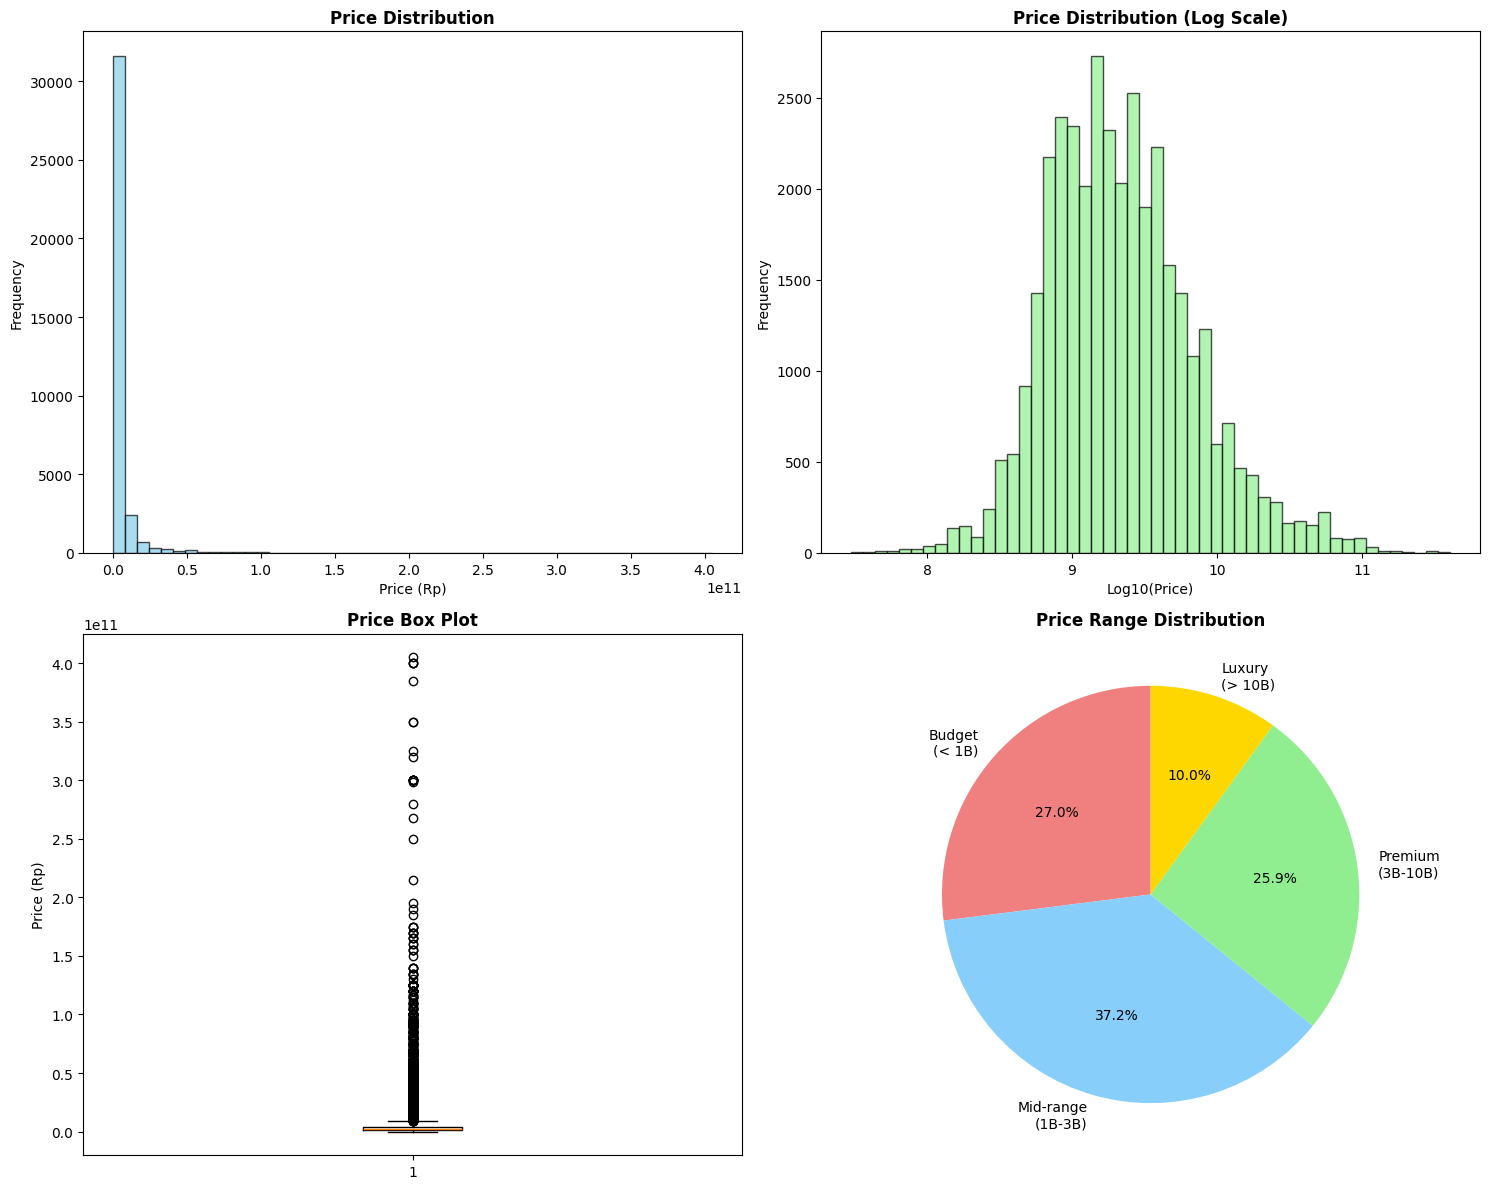

In [9]:
# Target variable (Price) analysis
def analyze_price_distribution(df):
    """Analyze the distribution of house prices"""
    price_col = 'price_in_rp'
    
    print("="*60)
    print("PRICE DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Basic statistics
    print("Basic Statistics:")
    print(f"  • Count: {df[price_col].count():,}")
    print(f"  • Mean: Rp {df[price_col].mean():,.0f}")
    print(f"  • Median: Rp {df[price_col].median():,.0f}")
    print(f"  • Std: Rp {df[price_col].std():,.0f}")
    print(f"  • Min: Rp {df[price_col].min():,.0f}")
    print(f"  • Max: Rp {df[price_col].max():,.0f}")
    
    # Quartiles
    q1 = df[price_col].quantile(0.25)
    q3 = df[price_col].quantile(0.75)
    iqr = q3 - q1
    
    print(f"\nQuartiles:")
    print(f"  • Q1 (25%): Rp {q1:,.0f}")
    print(f"  • Q3 (75%): Rp {q3:,.0f}")
    print(f"  • IQR: Rp {iqr:,.0f}")
    
    # Price ranges
    print(f"\nPrice Ranges:")
    budget = df[df[price_col] < 1e9].shape[0]
    mid_range = df[(df[price_col] >= 1e9) & (df[price_col] < 3e9)].shape[0]
    premium = df[(df[price_col] >= 3e9) & (df[price_col] < 10e9)].shape[0]
    luxury = df[df[price_col] >= 10e9].shape[0]
    
    total = len(df)
    print(f"  • Budget (< 1B): {budget:,} ({budget/total*100:.1f}%)")
    print(f"  • Mid-range (1B-3B): {mid_range:,} ({mid_range/total*100:.1f}%)")
    print(f"  • Premium (3B-10B): {premium:,} ({premium/total*100:.1f}%)")
    print(f"  • Luxury (> 10B): {luxury:,} ({luxury/total*100:.1f}%)")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram
    axes[0,0].hist(df[price_col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0,0].set_title('Price Distribution', fontweight='bold')
    axes[0,0].set_xlabel('Price (Rp)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    # Log-scale histogram
    axes[0,1].hist(np.log10(df[price_col]), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[0,1].set_title('Price Distribution (Log Scale)', fontweight='bold')
    axes[0,1].set_xlabel('Log10(Price)')
    axes[0,1].set_ylabel('Frequency')
    
    # Box plot
    axes[1,0].boxplot(df[price_col])
    axes[1,0].set_title('Price Box Plot', fontweight='bold')
    axes[1,0].set_ylabel('Price (Rp)')
    axes[1,0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Price ranges pie chart
    sizes = [budget, mid_range, premium, luxury]
    labels = ['Budget\n(< 1B)', 'Mid-range\n(1B-3B)', 'Premium\n(3B-10B)', 'Luxury\n(> 10B)']
    colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'gold']
    
    axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1,1].set_title('Price Range Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

analyze_price_distribution(df)

### **D. Analisis Kolom Kategorikal**

CATEGORICAL VARIABLES ANALYSIS
Found 9 categorical columns:
  • source: 1 unique values
  • url: 35992 unique values
  • title: 34181 unique values
  • address: 88 unique values
  • district: 87 unique values
  • city: 9 unique values
  • certificate: 2 unique values
  • furnishing: 3 unique values
  • hash_id: 35995 unique values


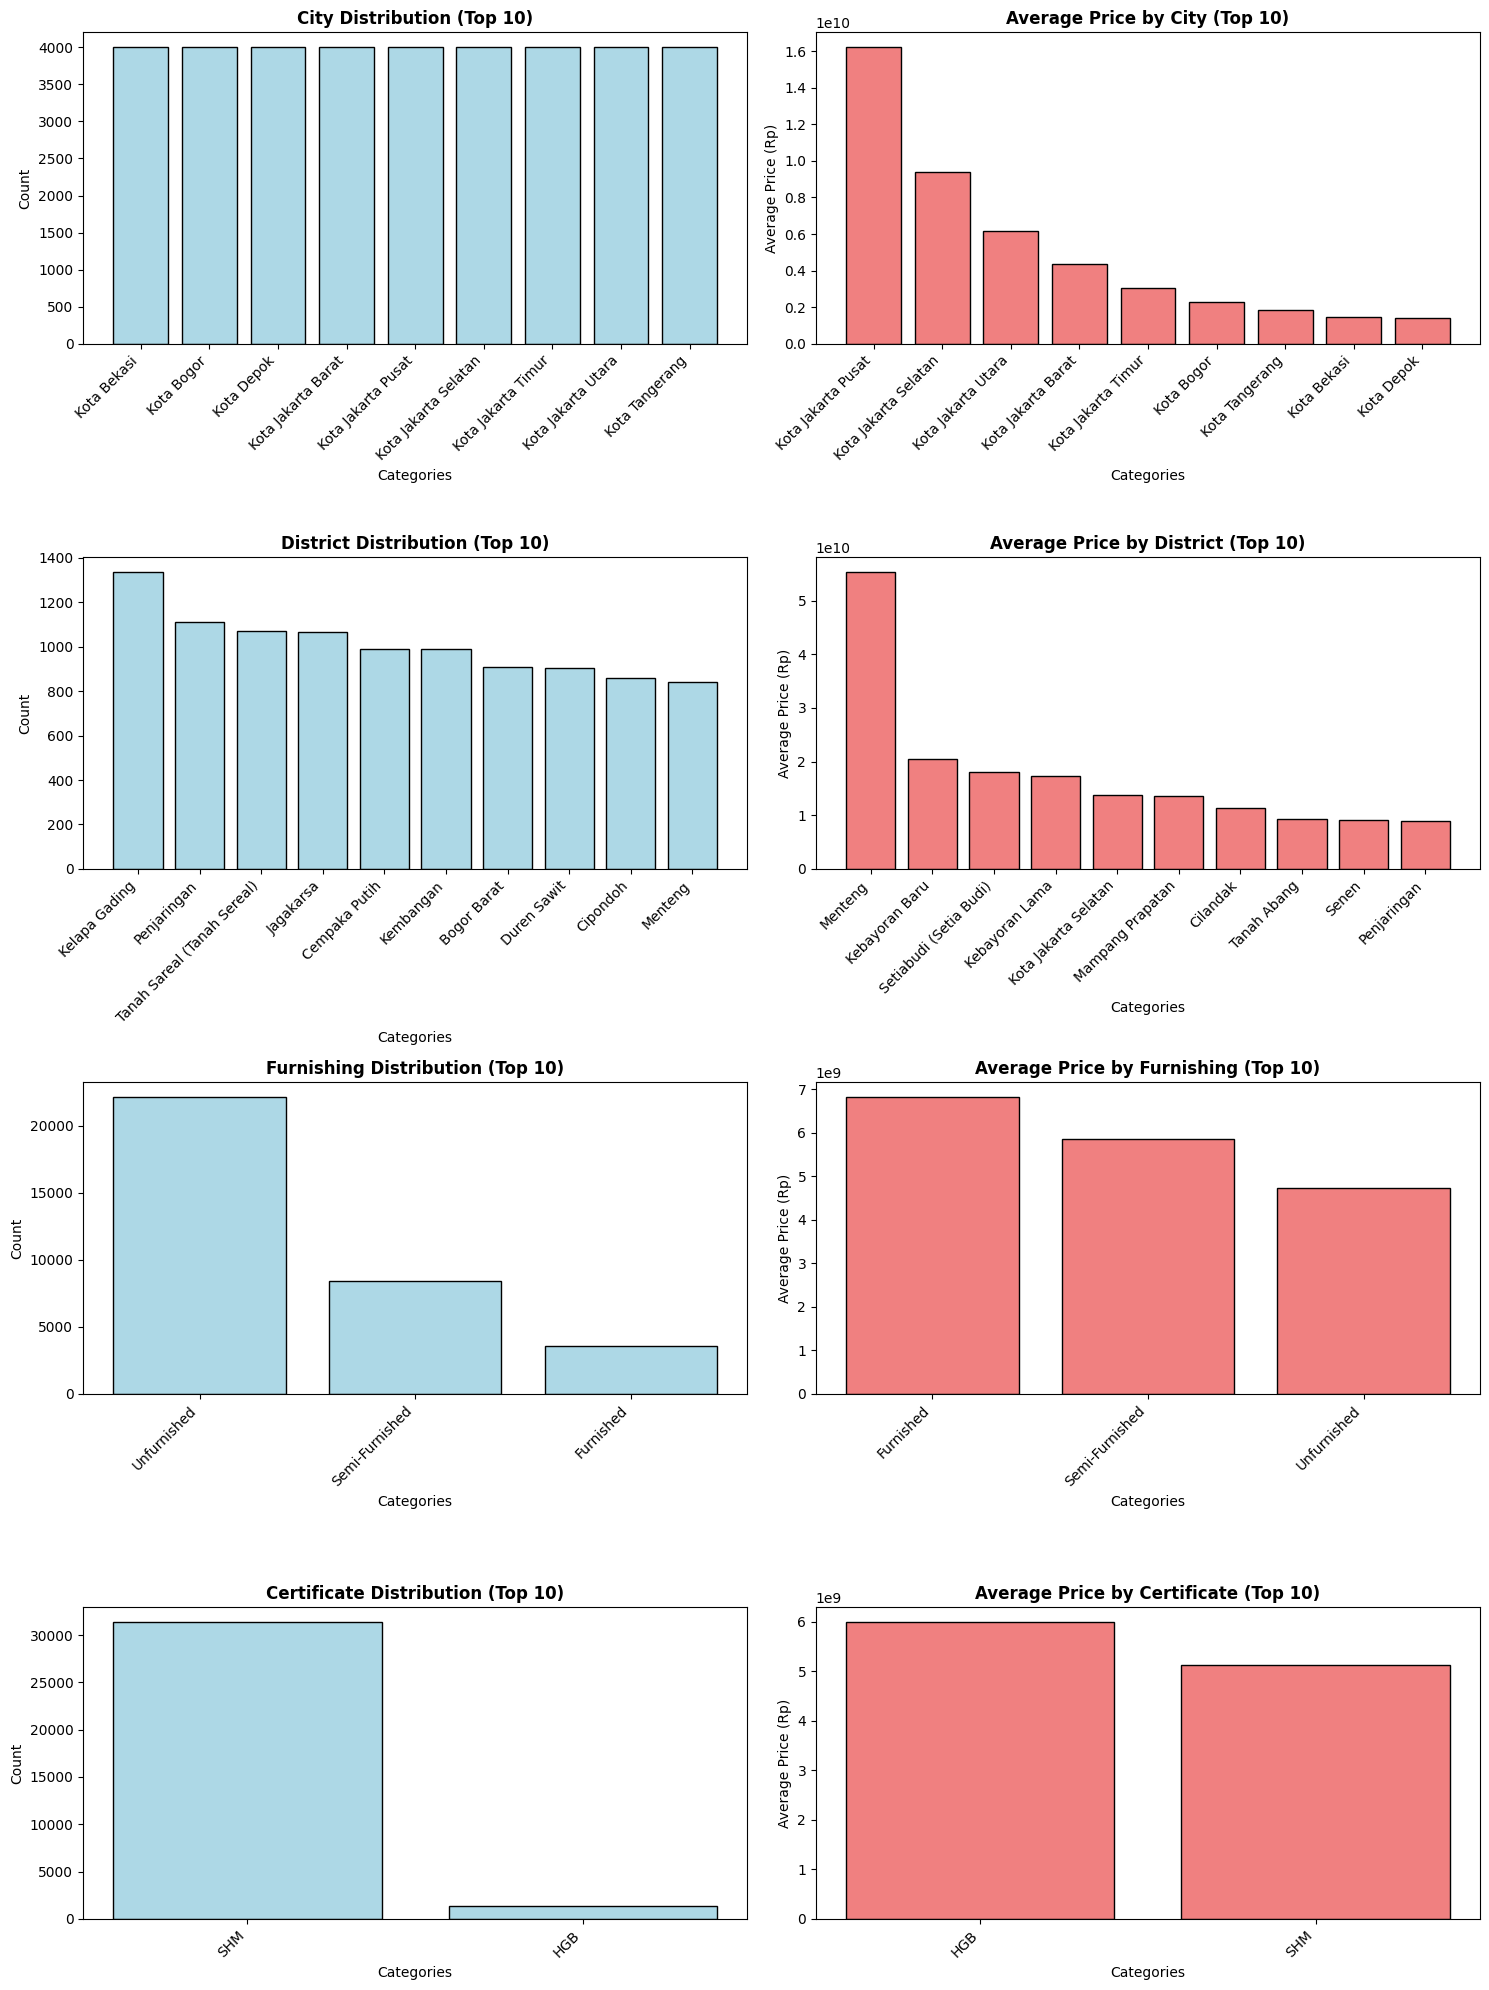

In [10]:
# Categorical variables analysis
def analyze_categorical_variables(df):
    """Analyze categorical variables and their relationship with price"""
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    print("="*60)
    print("CATEGORICAL VARIABLES ANALYSIS")
    print("="*60)
    print(f"Found {len(categorical_cols)} categorical columns:")
    
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"  • {col}: {unique_count} unique values")
    
    # Analyze key categorical variables
    key_categorical = ['city', 'district', 'furnishing', 'certificate']
    available_cats = [col for col in key_categorical if col in df.columns]
    
    if available_cats:
        fig, axes = plt.subplots(len(available_cats), 2, figsize=(15, 5*len(available_cats)))
        if len(available_cats) == 1:
            axes = axes.reshape(1, -1)
        
        for i, col in enumerate(available_cats):
            if col in df.columns:
                # Value counts
                value_counts = df[col].value_counts().head(10)
                
                # Count plot
                axes[i,0].bar(range(len(value_counts)), value_counts.values, color='lightblue', edgecolor='black')
                axes[i,0].set_title(f'{col.title()} Distribution (Top 10)', fontweight='bold')
                axes[i,0].set_xlabel('Categories')
                axes[i,0].set_ylabel('Count')
                axes[i,0].set_xticks(range(len(value_counts)))
                axes[i,0].set_xticklabels(value_counts.index, rotation=45, ha='right')
                
                # Average price by category
                if 'price_in_rp' in df.columns:
                    avg_price = df.groupby(col)['price_in_rp'].mean().sort_values(ascending=False).head(10)
                    axes[i,1].bar(range(len(avg_price)), avg_price.values, color='lightcoral', edgecolor='black')
                    axes[i,1].set_title(f'Average Price by {col.title()} (Top 10)', fontweight='bold')
                    axes[i,1].set_xlabel('Categories')
                    axes[i,1].set_ylabel('Average Price (Rp)')
                    axes[i,1].set_xticks(range(len(avg_price)))
                    axes[i,1].set_xticklabels(avg_price.index, rotation=45, ha='right')
                    axes[i,1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        
        plt.tight_layout()
        plt.show()

analyze_categorical_variables(df)

### **E. Analisis Kolom Numerik**

NUMERICAL VARIABLES ANALYSIS
Found 6 numerical columns (excluding price):
  • bedrooms
  • bathrooms
  • building_size_m2
  • land_size_m2
  • carports
  • electricity

Detailed Statistics:
           bedrooms     bathrooms  building_size_m2  land_size_m2  \
count  35549.000000  34017.000000      34049.000000  34083.000000   
mean       3.991252      3.018373        211.560721    200.968987   
std        3.612404      2.942183        250.333014    270.717555   
min        1.000000      1.000000          2.000000      2.000000   
25%        3.000000      2.000000         80.000000     77.000000   
50%        3.000000      3.000000        144.000000    120.000000   
75%        5.000000      4.000000        250.000000    216.000000   
max      119.000000    105.000000      10000.000000  10000.000000   

           carports   electricity  
count  13935.000000  1.508300e+04  
mean       1.732831  4.563366e+03  
std        8.554188  3.781742e+04  
min        1.000000  2.500000e+02  
25%     

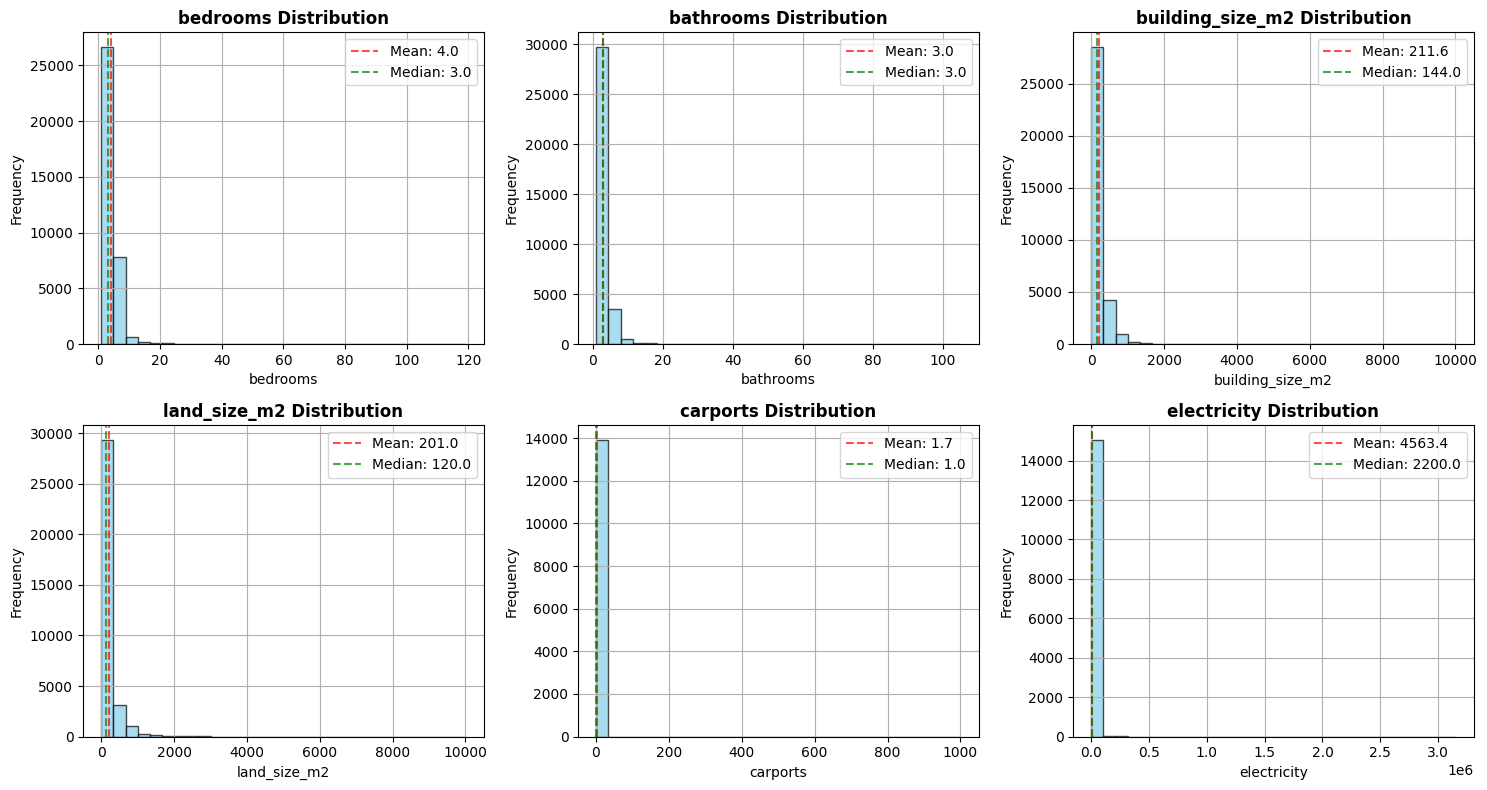

In [11]:
# Numerical variables analysis
def analyze_numerical_variables(df):
    """Analyze numerical variables and their distributions"""
    
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    numerical_cols = [col for col in numerical_cols if col != 'price_in_rp']  # Exclude target
    
    print("="*60)
    print("NUMERICAL VARIABLES ANALYSIS")
    print("="*60)
    print(f"Found {len(numerical_cols)} numerical columns (excluding price):")
    
    for col in numerical_cols:
        print(f"  • {col}")
    
    # Basic statistics
    print(f"\nDetailed Statistics:")
    print(df[numerical_cols].describe())
    
    # Distribution plots
    n_cols = 3
    n_rows = math.ceil(len(numerical_cols) / n_cols)
    
    if len(numerical_cols) > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
        
        for i, col in enumerate(numerical_cols):
            if i < len(axes):
                # Histogram with KDE
                df[col].hist(bins=30, alpha=0.7, ax=axes[i], edgecolor='black', color='skyblue')
                axes[i].set_title(f'{col} Distribution', fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                mean_val = df[col].mean()
                median_val = df[col].median()
                axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.1f}')
                axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.1f}')
                axes[i].legend()
        
        # Hide empty subplots
        for i in range(len(numerical_cols), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()

analyze_numerical_variables(df)

### **F. Analisis Korelasi**

CORRELATION ANALYSIS
Correlations with Price (sorted by strength):
  • building_size_m2    :  0.567 🟡 Moderate
  • land_size_m2        :  0.558 🟡 Moderate
  • bathrooms           :  0.253 ⚪ Very Weak
  • electricity         :  0.222 ⚪ Very Weak
  • bedrooms            :  0.202 ⚪ Very Weak
  • carports            :  0.056 ⚪ Very Weak


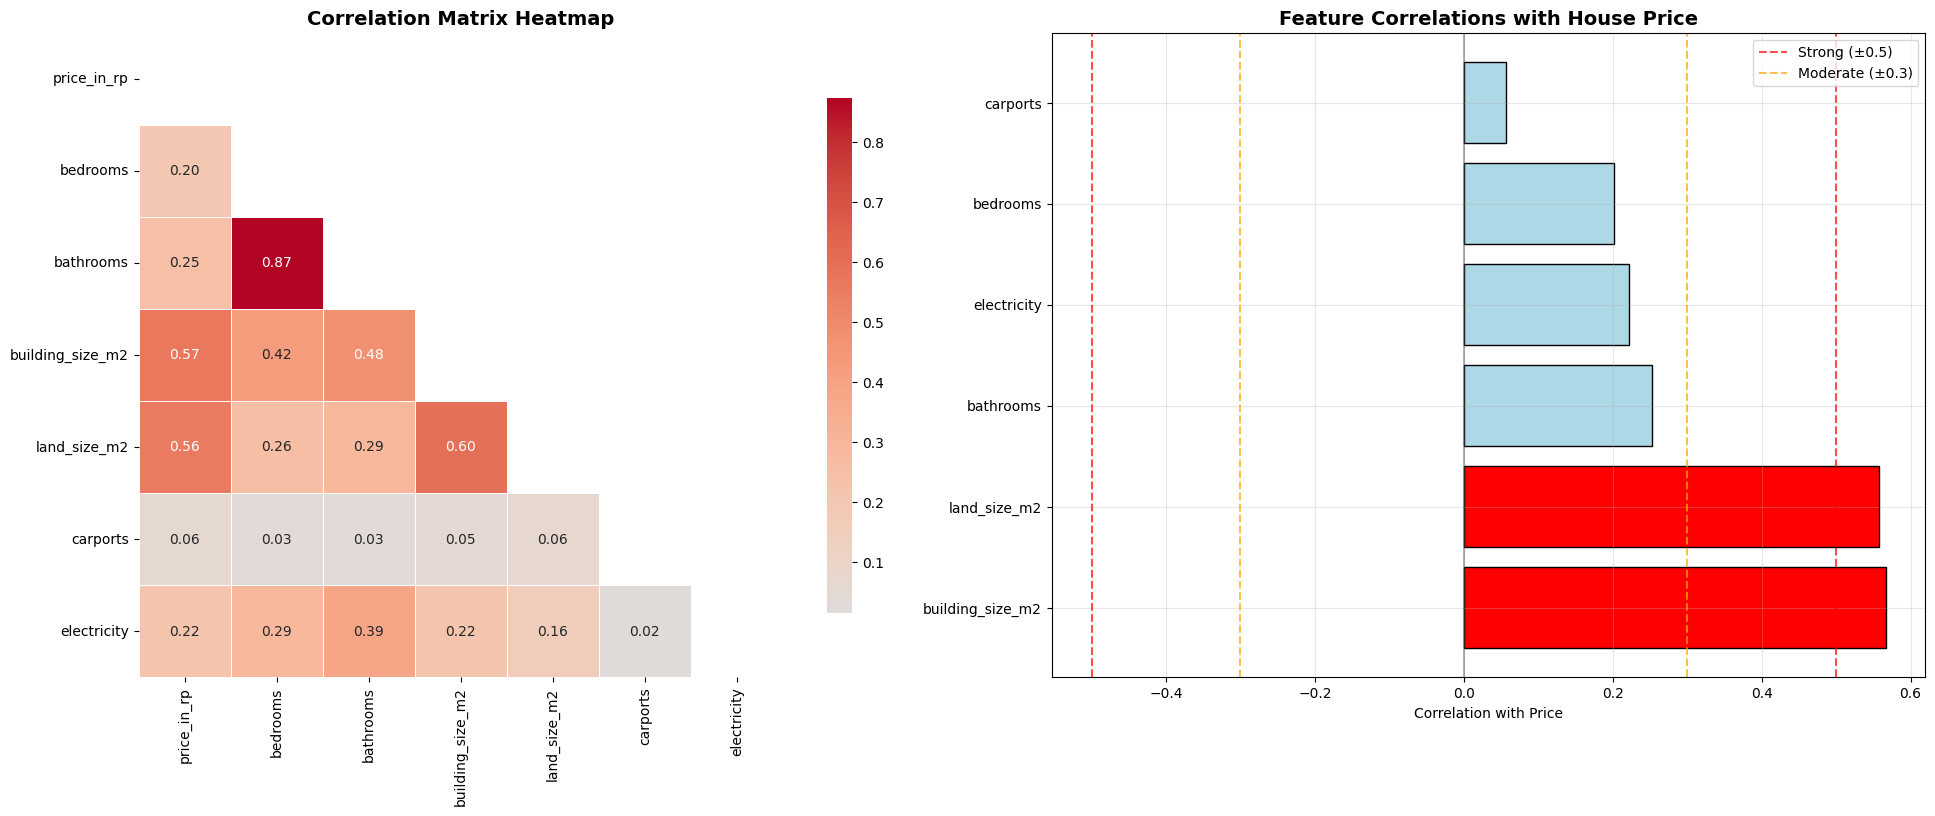


🔍 Multicollinearity Check (|correlation| > 0.8):
  ⚠️  bedrooms ↔ bathrooms: 0.874


In [12]:
# Correlation analysis
def analyze_correlations(df):
    """Analyze correlations between numerical variables and price"""
    
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    
    if 'price_in_rp' in numerical_cols:
        print("="*60)
        print("CORRELATION ANALYSIS")
        print("="*60)
        
        # Calculate correlations
        correlation_matrix = df[numerical_cols].corr()
        
        # Correlations with price
        price_correlations = correlation_matrix['price_in_rp'].sort_values(ascending=False)
        
        print("Correlations with Price (sorted by strength):")
        for var, corr in price_correlations.items():
            if var != 'price_in_rp':
                strength = ""
                if abs(corr) >= 0.7:
                    strength = "🔴 Strong"
                elif abs(corr) >= 0.5:
                    strength = "🟡 Moderate"
                elif abs(corr) >= 0.3:
                    strength = "🟢 Weak"
                else:
                    strength = "⚪ Very Weak"
                
                print(f"  • {var:20s}: {corr:6.3f} {strength}")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Full correlation heatmap
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
        sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                   cmap='coolwarm', center=0, ax=axes[0],
                   square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        axes[0].set_title('Correlation Matrix Heatmap', fontweight='bold', fontsize=14)
        
        # Price correlations bar plot
        price_corr_filtered = price_correlations.drop('price_in_rp')
        colors = ['red' if abs(x) >= 0.5 else 'orange' if abs(x) >= 0.3 else 'lightblue' for x in price_corr_filtered.values]
        
        axes[1].barh(range(len(price_corr_filtered)), price_corr_filtered.values, color=colors, edgecolor='black')
        axes[1].set_yticks(range(len(price_corr_filtered)))
        axes[1].set_yticklabels(price_corr_filtered.index)
        axes[1].set_xlabel('Correlation with Price')
        axes[1].set_title('Feature Correlations with House Price', fontweight='bold', fontsize=14)
        axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
        axes[1].grid(True, alpha=0.3)
        
        # Add correlation strength lines
        axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Strong (±0.5)')
        axes[1].axvline(x=-0.5, color='red', linestyle='--', alpha=0.7)
        axes[1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Moderate (±0.3)')
        axes[1].axvline(x=-0.3, color='orange', linestyle='--', alpha=0.7)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Identify highly correlated feature pairs (multicollinearity check)
        print(f"\n🔍 Multicollinearity Check (|correlation| > 0.8):")
        high_corr_pairs = []
        
        for i in range(len(correlation_matrix.columns)):
            for j in range(i+1, len(correlation_matrix.columns)):
                col1 = correlation_matrix.columns[i]
                col2 = correlation_matrix.columns[j]
                corr_val = correlation_matrix.iloc[i, j]
                
                if abs(corr_val) > 0.8:
                    high_corr_pairs.append((col1, col2, corr_val))
        
        if high_corr_pairs:
            for col1, col2, corr in high_corr_pairs:
                print(f"  ⚠️  {col1} ↔ {col2}: {corr:.3f}")
        else:
            print("  ✅ No high multicollinearity detected")

analyze_correlations(df)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### **A. Menghapus atau Menangani Data Kosong (Missing Values)**

In [13]:
df = df.drop(['source', 'url', 'title', 'address', 'scraped_at', 'hash_id'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       36000 non-null  int64  
 1   district          36000 non-null  object 
 2   city              36000 non-null  object 
 3   bedrooms          35549 non-null  float64
 4   bathrooms         34017 non-null  float64
 5   building_size_m2  34049 non-null  float64
 6   land_size_m2      34083 non-null  float64
 7   carports          13935 non-null  float64
 8   certificate       32723 non-null  object 
 9   furnishing        34159 non-null  object 
 10  electricity       15083 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.0+ MB


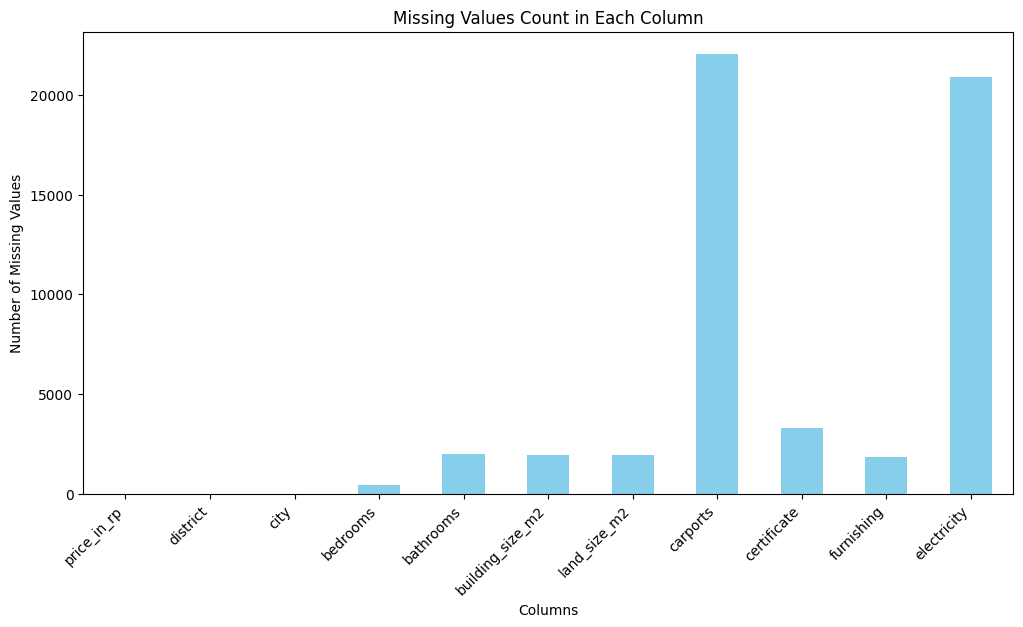

In [14]:
def show_is_null_plot(df):
    nan_counts = df.isnull().sum()
    plt.figure(figsize=(12, 6))
    nan_counts.plot(kind='bar', color='skyblue')
    plt.title('Missing Values Count in Each Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.show()

show_is_null_plot(df)

Menghapus Data Kosong pada Kolom dengan Jumlah Sedikit

In [15]:
less_nan = df[df['district'].isna() | df['city'].isna() | df['bedrooms'].isna() | df['bathrooms'].isna() | df['land_size_m2'].isna() | df['building_size_m2'].isna()]
less_nan

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,carports,certificate,furnishing,electricity
1,1400000000,Medansatria (Medan Satria),Kota Bekasi,3.0,NaN,150.0,112.0,2.0,SHM,Semi-Furnished,2200.0
9,885000000,Jatiasih,Kota Bekasi,3.0,2.0,NaN,83.0,2.0,SHM,Unfurnished,2200.0
16,932645000,Rawalumbu,Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,None,NaN
18,824500000,Jatiasih,Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,None,NaN
20,517000000,Mustikajaya (Mustika Jaya),Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...
35915,3400000000,Cibodas,Kota Tangerang,4.0,3.0,NaN,582.0,2.0,SHM,Unfurnished,5500.0
35916,1450000000,Pinang (Penang),Kota Tangerang,2.0,1.0,90.0,NaN,2.0,SHM,Unfurnished,2200.0
35946,800000000,Pinang (Penang),Kota Tangerang,4.0,2.0,170.0,NaN,1.0,SHM,Unfurnished,1300.0
35972,1800000000,Larangan,Kota Tangerang,4.0,2.0,NaN,161.0,2.0,SHM,Semi-Furnished,2200.0


In [16]:
clean_df = df.drop(less_nan.index, axis=0)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31036 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       31036 non-null  int64  
 1   district          31036 non-null  object 
 2   city              31036 non-null  object 
 3   bedrooms          31036 non-null  float64
 4   bathrooms         31036 non-null  float64
 5   building_size_m2  31036 non-null  float64
 6   land_size_m2      31036 non-null  float64
 7   carports          9458 non-null   float64
 8   certificate       28107 non-null  object 
 9   furnishing        29640 non-null  object 
 10  electricity       10572 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 2.8+ MB


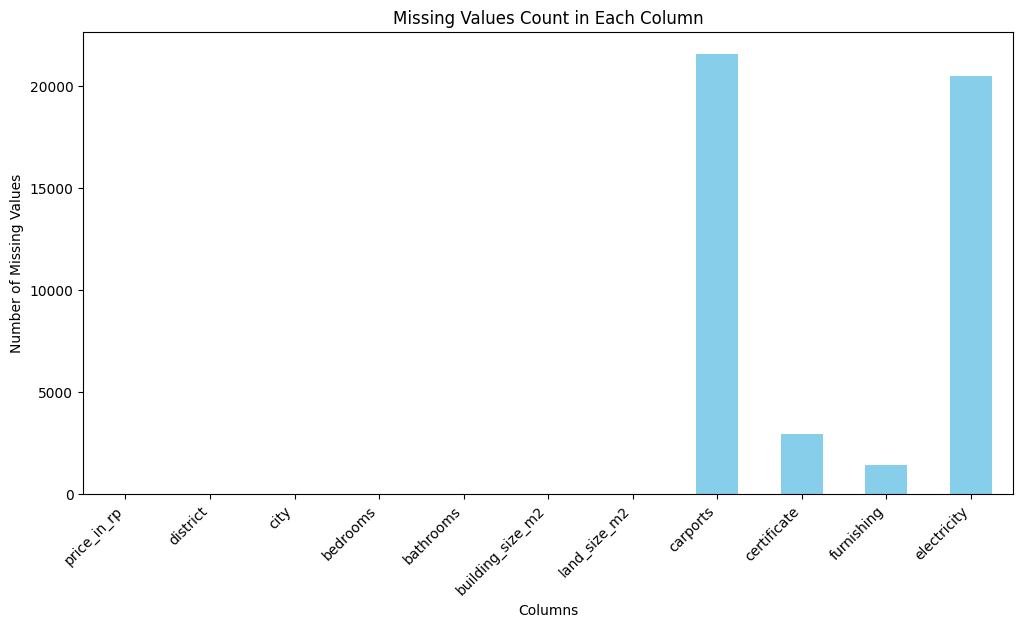

In [17]:
show_is_null_plot(clean_df)

Mengisi Nilai Kosong pada Kolom Kategorikal dengan Nilai Terbanyak

In [18]:
categorical_features = ['certificate', 'furnishing']

imputer_cat = SimpleImputer(strategy='most_frequent')
clean_df[categorical_features] = imputer_cat.fit_transform(clean_df[categorical_features])

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31036 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       31036 non-null  int64  
 1   district          31036 non-null  object 
 2   city              31036 non-null  object 
 3   bedrooms          31036 non-null  float64
 4   bathrooms         31036 non-null  float64
 5   building_size_m2  31036 non-null  float64
 6   land_size_m2      31036 non-null  float64
 7   carports          9458 non-null   float64
 8   certificate       28107 non-null  object 
 9   furnishing        29640 non-null  object 
 10  electricity       10572 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 2.8+ MB


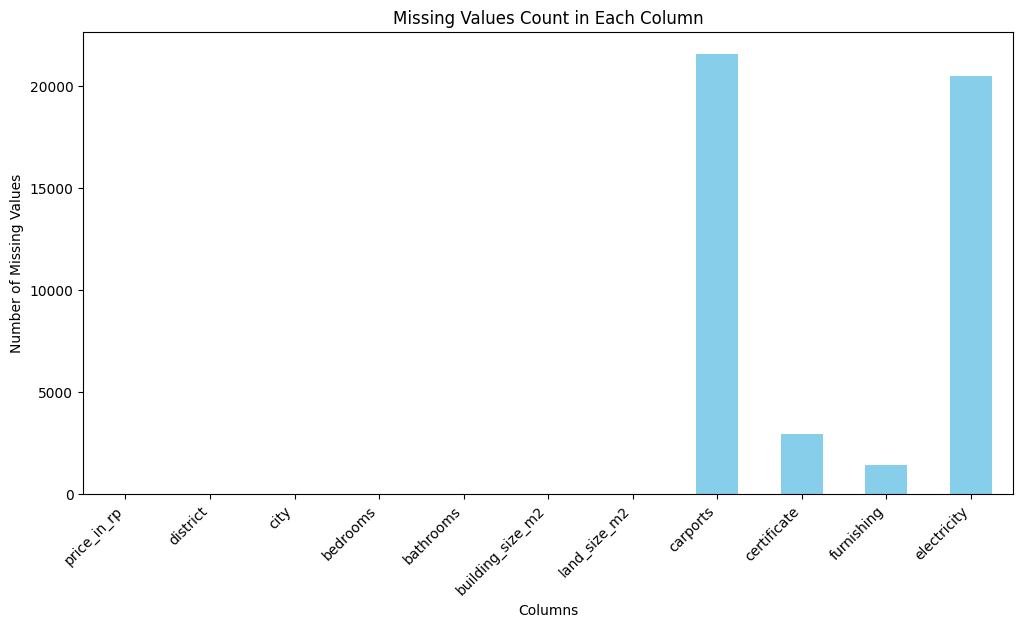

In [19]:
show_is_null_plot(clean_df)

Hapus Kolom yang Memiliki Data Kosong > 40%

In [20]:
clean_df = clean_df.drop(['electricity', 'carports'], axis=1)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31036 entries, 0 to 35999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       31036 non-null  int64  
 1   district          31036 non-null  object 
 2   city              31036 non-null  object 
 3   bedrooms          31036 non-null  float64
 4   bathrooms         31036 non-null  float64
 5   building_size_m2  31036 non-null  float64
 6   land_size_m2      31036 non-null  float64
 7   certificate       28107 non-null  object 
 8   furnishing        29640 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 2.4+ MB


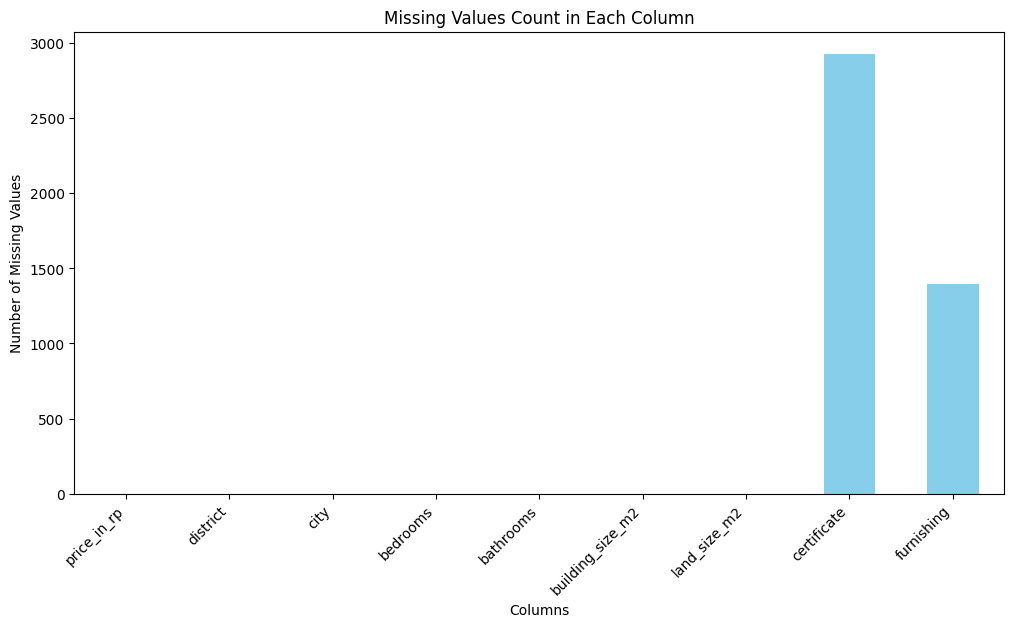

In [21]:
show_is_null_plot(clean_df)

### **B. Menghapus Data Duplikat**

In [22]:
duplicated_count = clean_df.duplicated().sum()
duplicated_count

2548

In [23]:
dropped_df = clean_df.drop_duplicates()
dropped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28488 entries, 0 to 35999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       28488 non-null  int64  
 1   district          28488 non-null  object 
 2   city              28488 non-null  object 
 3   bedrooms          28488 non-null  float64
 4   bathrooms         28488 non-null  float64
 5   building_size_m2  28488 non-null  float64
 6   land_size_m2      28488 non-null  float64
 7   certificate       25755 non-null  object 
 8   furnishing        27123 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 2.2+ MB


### **C. Deteksi dan Penanganan Outlier**

In [24]:
filtered_df = dropped_df[
    (dropped_df['price_in_rp'] >= 3e8) & (dropped_df['price_in_rp'] <= 5e10) & 
    (dropped_df['bedrooms'] <= 20) & (dropped_df['bathrooms'] <= 20) &
    (dropped_df['building_size_m2'] <= 2000) & (dropped_df['land_size_m2'] <= 2000)
]
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27208 entries, 0 to 35999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       27208 non-null  int64  
 1   district          27208 non-null  object 
 2   city              27208 non-null  object 
 3   bedrooms          27208 non-null  float64
 4   bathrooms         27208 non-null  float64
 5   building_size_m2  27208 non-null  float64
 6   land_size_m2      27208 non-null  float64
 7   certificate       24698 non-null  object 
 8   furnishing        25876 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 2.1+ MB


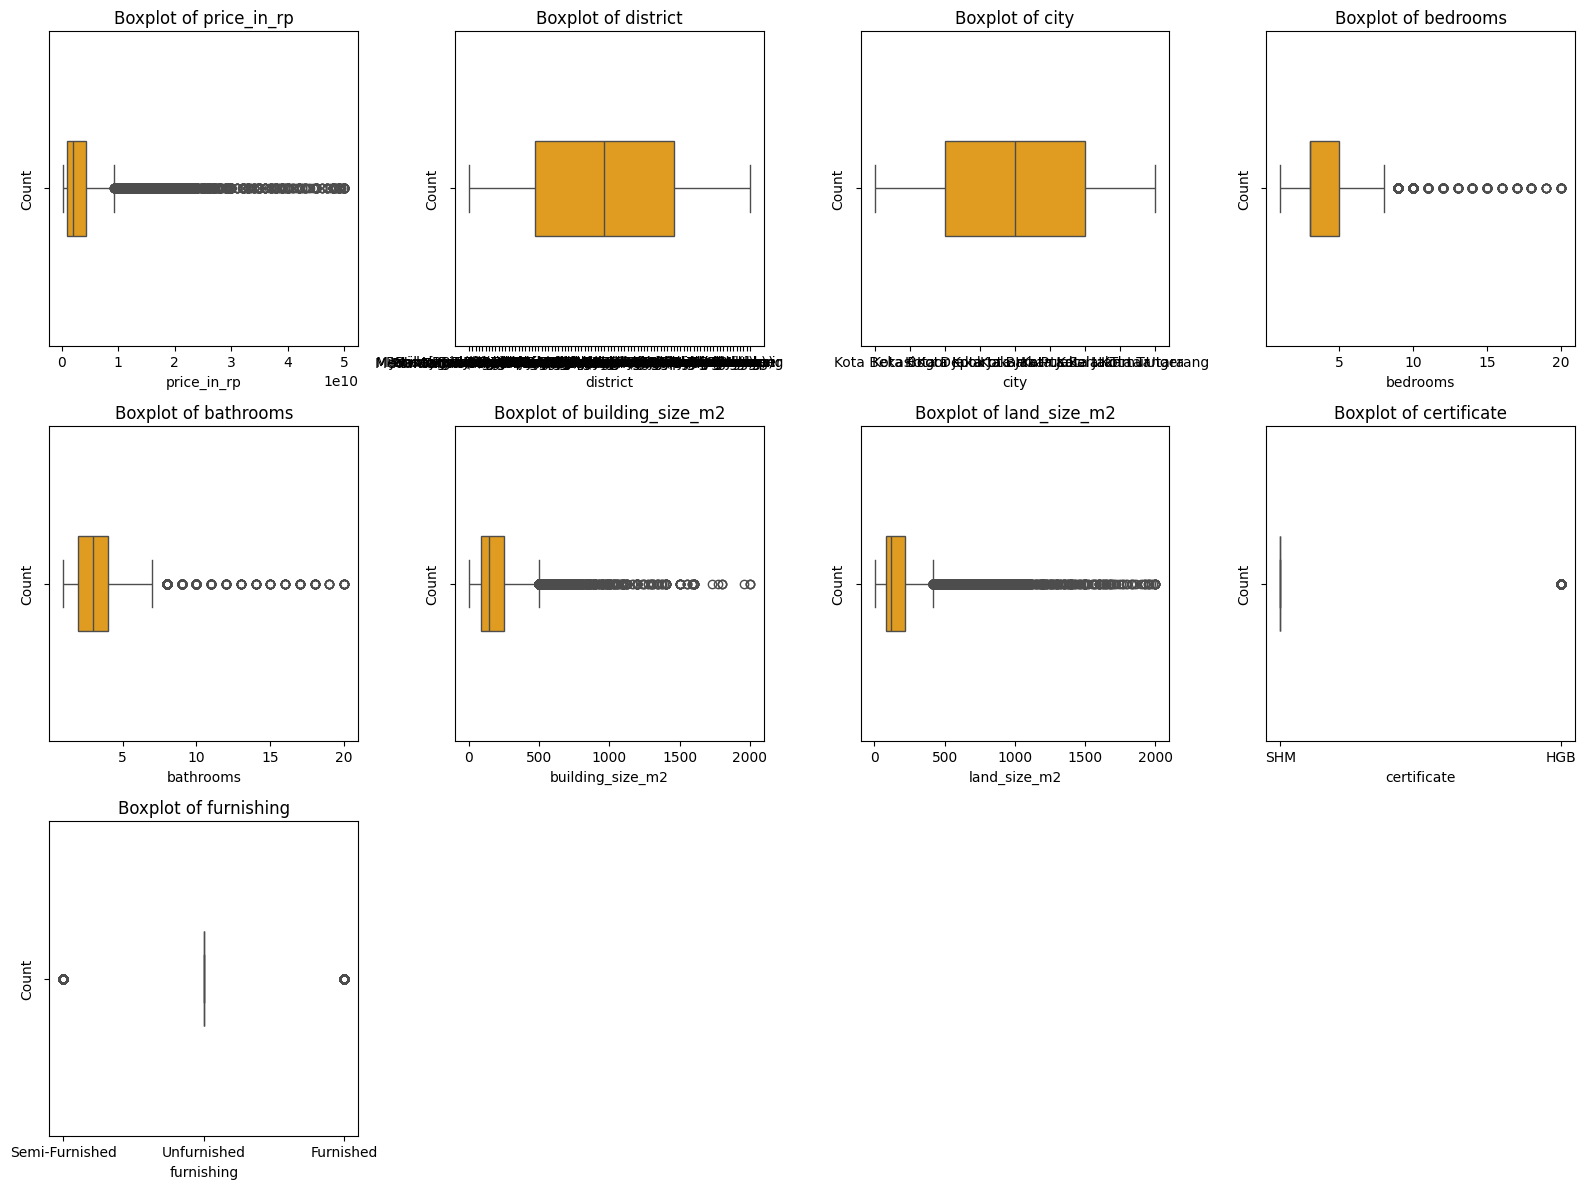

In [25]:
num_cols = 4
num_rows = math.ceil(len(filtered_df.columns) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(filtered_df.columns):
    sns.boxplot(x=filtered_df[col], ax=axes[i], color='orange', width=0.3)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
for j in range(len(filtered_df.columns), len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [26]:
def handle_outliers(inserted_df, columns):
    df_no_outliers = inserted_df.copy()
    for column in columns:
        Q1 = df_no_outliers[column].quantile(0.25)
        Q3 = df_no_outliers[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR # Menggunakan 2*IQR untuk batas yang lebih luas
        upper_bound = Q3 + 2 * IQR # Menggunakan 2*IQR untuk batas yang lebih luas

        print(f"lower_bound: {lower_bound}, upper_bound: {upper_bound} for column {column}")
        
        outlier_mask = (df_no_outliers[column] < lower_bound) | (df_no_outliers[column] > upper_bound)
        outliers_count = outlier_mask.sum()
        print(f"Column {column}: {outliers_count} outliers detected\n")
        df_no_outliers = df_no_outliers[~outlier_mask]
    
    print(f"\nShape before outlier removal: {inserted_df.shape}")
    print(f"Shape after outlier removal: {df_no_outliers.shape}")
    
    return df_no_outliers

columns_to_check = ['land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms']
filtered_df = handle_outliers(filtered_df, columns_to_check)

lower_bound: -190.0, upper_bound: 485.0 for column land_size_m2
Column land_size_m2: 1923 outliers detected

lower_bound: -200.0, upper_bound: 500.0 for column building_size_m2
Column building_size_m2: 728 outliers detected

lower_bound: 1.0, upper_bound: 6.0 for column bedrooms
Column bedrooms: 1076 outliers detected

lower_bound: 0.0, upper_bound: 5.0 for column bathrooms
Column bathrooms: 250 outliers detected


Shape before outlier removal: (27208, 9)
Shape after outlier removal: (23231, 9)


### **D. Encoding Data Kategorikal**

In [27]:
encoded_df = filtered_df.copy()

In [28]:
furnishing_ordinal = encoded_df['furnishing'].unique()
furnishing_ordinal

array([None, 'Semi-Furnished', 'Unfurnished', 'Furnished'], dtype=object)

In [29]:
furnishing_encoder = OrdinalEncoder(categories=[furnishing_ordinal], dtype=int)
encoded_df['furnishing_encoded'] = furnishing_encoder.fit_transform(encoded_df[['furnishing']])
encoded_df.head()

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,None,0
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,None,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,None,0
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,2


In [30]:
city_label = encoded_df['city'].unique()
city_label

array(['Kota Bekasi', 'Kota Bogor', 'Kota Depok', 'Kota Jakarta Barat',
       'Kota Jakarta Pusat', 'Kota Jakarta Selatan', 'Kota Jakarta Timur',
       'Kota Jakarta Utara', 'Kota Tangerang'], dtype=object)

In [31]:
city_encoder = LabelEncoder()
encoded_df['city_encoded'] = city_encoder.fit_transform(encoded_df['city'])
encoded_df.head()

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,None,0,0
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,None,0,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,None,0,0
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,2,0


In [32]:
district_label = encoded_df['district'].unique()
district_label

array(['Mustikajaya (Mustika Jaya)', 'Medansatria (Medan Satria)',
       'Bekasi Barat', 'Rawalumbu', 'Pondokgede (Pondok Gede)',
       'Bekasi Timur', 'Jatiasih', 'Jatisampurna (Jati Sampurna)',
       'Pondokmelati (Pondok Melati)', 'Bekasi Utara', 'Bekasi Selatan',
       'Bantargebang (Bantar Gebang)', 'Bogor Utara', 'Bogor Barat',
       'Bogor Selatan', 'Tanah Sareal (Tanah Sereal)', 'Bogor Tengah',
       'Bogor Timur', 'Sawangan', 'Cipayung', 'Bojongsari', 'Limo',
       'Cimanggis', 'Pancoran Mas', 'Beji', 'Cilodong', 'Sukmajaya',
       'Tapos', 'Cinere', 'Gunung Sindur', 'Kembangan',
       'Grogol Petamburan', 'Kalideres', 'Cengkareng', 'Kebon Jeruk',
       'Pal Merah (Palmerah)', 'Tambora', 'Taman Sari', 'Sawah Besar',
       'Cempaka Putih', 'Johar Baru', 'Gambir', 'Kemayoran', 'Menteng',
       'Senen', 'Tanah Abang', 'Kebayoran Lama', 'Jagakarsa',
       'Pasar Minggu', 'Setiabudi (Setia Budi)', 'Cilandak',
       'Pesanggrahan', 'Mampang Prapatan', 'Kebayoran Baru',

In [33]:
district_encoder = LabelEncoder()
encoded_df['district_encoded'] = district_encoder.fit_transform(encoded_df['district'])
encoded_df.head()

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded,district_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,None,0,0,56
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,None,0,0,54
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0,3
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,None,0,0,71
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,2,0,68


In [34]:
certificate_label = encoded_df['certificate'].unique()
certificate_label

array(['SHM', 'HGB', None], dtype=object)

In [35]:
certificate_encoder = LabelEncoder()
encoded_df['certificate_encoded'] = certificate_encoder.fit_transform(encoded_df['certificate'])
encoded_df.head()

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded,district_encoded,certificate_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,None,0,0,56,1
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,None,0,0,54,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0,3,1
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,None,0,0,71,1
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,2,0,68,1


### **E. Normalisasi atau Standarisasi Fitur**

In [36]:
model_df = encoded_df.copy()

# Kolom numerik asli yang akan di-scale
numeric_feature_cols = [
    'bedrooms',
    'bathrooms',
    'land_size_m2',
    'building_size_m2'
]

# Kolom hasil encoding tetap disimpan, tetapi tidak di-scale
categorical_encoded_cols = [
    'city_encoded',
    'district_encoded',
    'furnishing_encoded',
    'certificate_encoded'
]

# Cek fitur yang dipakai
feature_cols = numeric_feature_cols + categorical_encoded_cols
features = model_df[feature_cols]
prices = model_df['price_in_rp']

print("Features shape:", features.shape)
print("Prices shape:", prices.shape)

Features shape: (23231, 8)
Prices shape: (23231,)


In [37]:
# Scaling hanya untuk fitur numerik asli
X_scaler = RobustScaler()
features_scaled = features.copy()

features_scaled[numeric_feature_cols] = X_scaler.fit_transform(features[numeric_feature_cols])

print("Scaled features shape:", features_scaled.shape)
features_scaled.head()

Scaled features shape: (23231, 8)


,bedrooms,bathrooms,land_size_m2,building_size_m2,city_encoded,district_encoded,furnishing_encoded,certificate_encoded
0,-1.0,-1.0,-0.400000,-0.658537,0,56,0,1
2,-1.0,-1.0,-0.715789,-0.585366,0,54,0,0
3,0.0,0.0,-0.189474,-0.081301,0,3,1,1
4,0.0,0.0,-0.473684,-0.406504,0,71,0,1
5,0.0,1.0,-0.178947,-0.097561,0,68,2,1


In [38]:
# Ringkasan hasil normalisasi
print("Kolom yang di-scale:")
print(numeric_feature_cols)

print("\nKolom yang tidak di-scale:")
print(categorical_encoded_cols)

print("\nInfo data hasil preprocessing:")
features_scaled.info()

Kolom yang di-scale:
['bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2']

Kolom yang tidak di-scale:
['city_encoded', 'district_encoded', 'furnishing_encoded', 'certificate_encoded']

Info data hasil preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 23231 entries, 0 to 35999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bedrooms             23231 non-null  float64
 1   bathrooms            23231 non-null  float64
 2   land_size_m2         23231 non-null  float64
 3   building_size_m2     23231 non-null  float64
 4   city_encoded         23231 non-null  int32  
 5   district_encoded     23231 non-null  int32  
 6   furnishing_encoded   23231 non-null  int32  
 7   certificate_encoded  23231 non-null  int32  
dtypes: float64(4), int32(4)
memory usage: 1.2 MB
